# 🗓️ Analyse de la Saisonnalité — SalesTeam AI

> **Objectif** : Déterminer si des patterns saisonniers récurrents et significatifs existent dans les données de commandes. Si oui, les quantifier, les expliquer, et identifier les features ML exploitables.

> **Approche** : Investigation rigoureuse — on ne suppose rien sur les colonnes, on découvre d'abord le schéma réel, puis on bâtit les analyses visuelles et statistiques étape par étape.

---
## Table des Matières
1. Inspection du schéma et de la structure temporelle
2. Activité globale dans le temps
3. Patterns mensuels et saisonniers
4. Patterns par jour de la semaine
5. Heatmaps : mois × année
6. Décomposition tendance / saisonnalité / résidu
7. Saisonnalité par catégorie et par produit
8. Comportement client dans le temps
9. Quantification statistique de la saisonnalité
10. Features ML dérivées de la saisonnalité
11. **Conclusions analytiques**

## 0. Setup & Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats

# ── Style global ──
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})
PALETTE = sns.color_palette('tab10')

print('Packages loaded successfully.')

Packages loaded successfully.


---
## 1. Inspection du Schéma et de la Structure Temporelle

On commence toujours par **découvrir le schéma réel** — jamais supposer les noms de colonnes.
On merge les deux fichiers propres : `commandes_clean.csv` (en-tête de commande) et `lignes_clean.csv` (lignes produits).

In [3]:
# ── Charger les données ──
df_cmd = pd.read_csv('../data/processed/commandes_clean.csv', parse_dates=['date_commande'])
df_lig = pd.read_csv('../data/processed/lignes_clean.csv')

print('=== commandes_clean.csv — Colonnes ===')
print(df_cmd.dtypes)
print()
print('=== lignes_clean.csv — Colonnes ===')
print(df_lig.dtypes)

=== commandes_clean.csv — Colonnes ===
code_facture              object
code_client               object
date_commande     datetime64[ns]
ref_commercial            object
societe                   object
mois                       int64
annee                      int64
annee_mois                object
jour_semaine               int64
trimestre                  int64
dtype: object

=== lignes_clean.csv — Colonnes ===
code_facture     object
quantite          int64
code_article     object
designation      object
categorie        object
societe_ligne    object
is_bulk_order      bool
dtype: object


In [4]:
# ── Merge ──
df = df_cmd.merge(df_lig, on='code_facture', how='inner')

# ── Colonnes temporelles enrichies ──
df['week_of_year']  = df['date_commande'].dt.isocalendar().week.astype(int)
df['day_name']      = df['date_commande'].dt.day_name()
df['month_name']    = df['date_commande'].dt.strftime('%b')
df['year_month']    = df['date_commande'].dt.to_period('M')

print(f'Shape après merge : {df.shape}')
print(f'Période           : {df["date_commande"].min().date()} → {df["date_commande"].max().date()}')
print(f'Années disponibles: {sorted(df["annee"].unique())}')
print(f'Clients uniques   : {df["code_client"].nunique()}')
print(f'Produits uniques  : {df["code_article"].nunique()}')
print(f'Catégories        : {df["categorie"].nunique()}')
print(f'Total lignes      : {len(df):,}')
print()
print('Valeurs manquantes:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape après merge : (78530, 20)
Période           : 2024-01-08 → 2026-06-22
Années disponibles: [np.int64(2024), np.int64(2025), np.int64(2026)]
Clients uniques   : 737
Produits uniques  : 632
Catégories        : 11
Total lignes      : 78,530

Valeurs manquantes:
Series([], dtype: int64)


In [5]:
# ── Vérifier la granularité temporelle ──
daily_orders = df.groupby('date_commande')['code_facture'].nunique()

print(f'Nombre de jours avec au moins 1 commande : {len(daily_orders)}')
print(f'Période calendaire totale : {(df["date_commande"].max() - df["date_commande"].min()).days} jours')
print(f'Taux de couverture : {len(daily_orders) / (df["date_commande"].max() - df["date_commande"].min()).days * 100:.1f}%')

# Détecter les jours sans activité
all_days = pd.date_range(df['date_commande'].min(), df['date_commande'].max(), freq='D')
missing_days = all_days.difference(daily_orders.index)
print(f'\nJours sans commande : {len(missing_days)}')
print(f'Dont weekends estimés (sam/dim) : ~{(len(all_days)//7)*2}')
print(f'Distribution jour_semaine (0=lundi) :')
print(df['jour_semaine'].value_counts().sort_index())

Nombre de jours avec au moins 1 commande : 612
Période calendaire totale : 896 jours
Taux de couverture : 68.3%

Jours sans commande : 285
Dont weekends estimés (sam/dim) : ~256
Distribution jour_semaine (0=lundi) :
jour_semaine
0    14648
1    17838
2    15346
3    13390
4    16433
5      849
6       26
Name: count, dtype: int64


### Interprétation — Structure Temporelle

- **Granularité** : Les données sont au niveau de la **ligne de commande** (un produit par ligne). On travaillera à des agrégations quotidiennes, hebdomadaires et mensuelles.
- **Période** : Janvier 2024 → Juin 2026, soit environ **2,5 ans** de données.
- **Jours ouvrés** : L'activité est quasi-exclusivement du lundi au vendredi (jours 0–4), avec très peu de samedi et presque zéro dimanche. C'est un contexte B2B.
- **Variable métier principale** : `quantite` (unités vendues) et `code_facture` (nombre de commandes / visites commerciales).

---
## 2. Activité Globale dans le Temps

Objectif : identifier la **tendance générale** et repérer des anomalies avant d'analyser la saisonnalité.

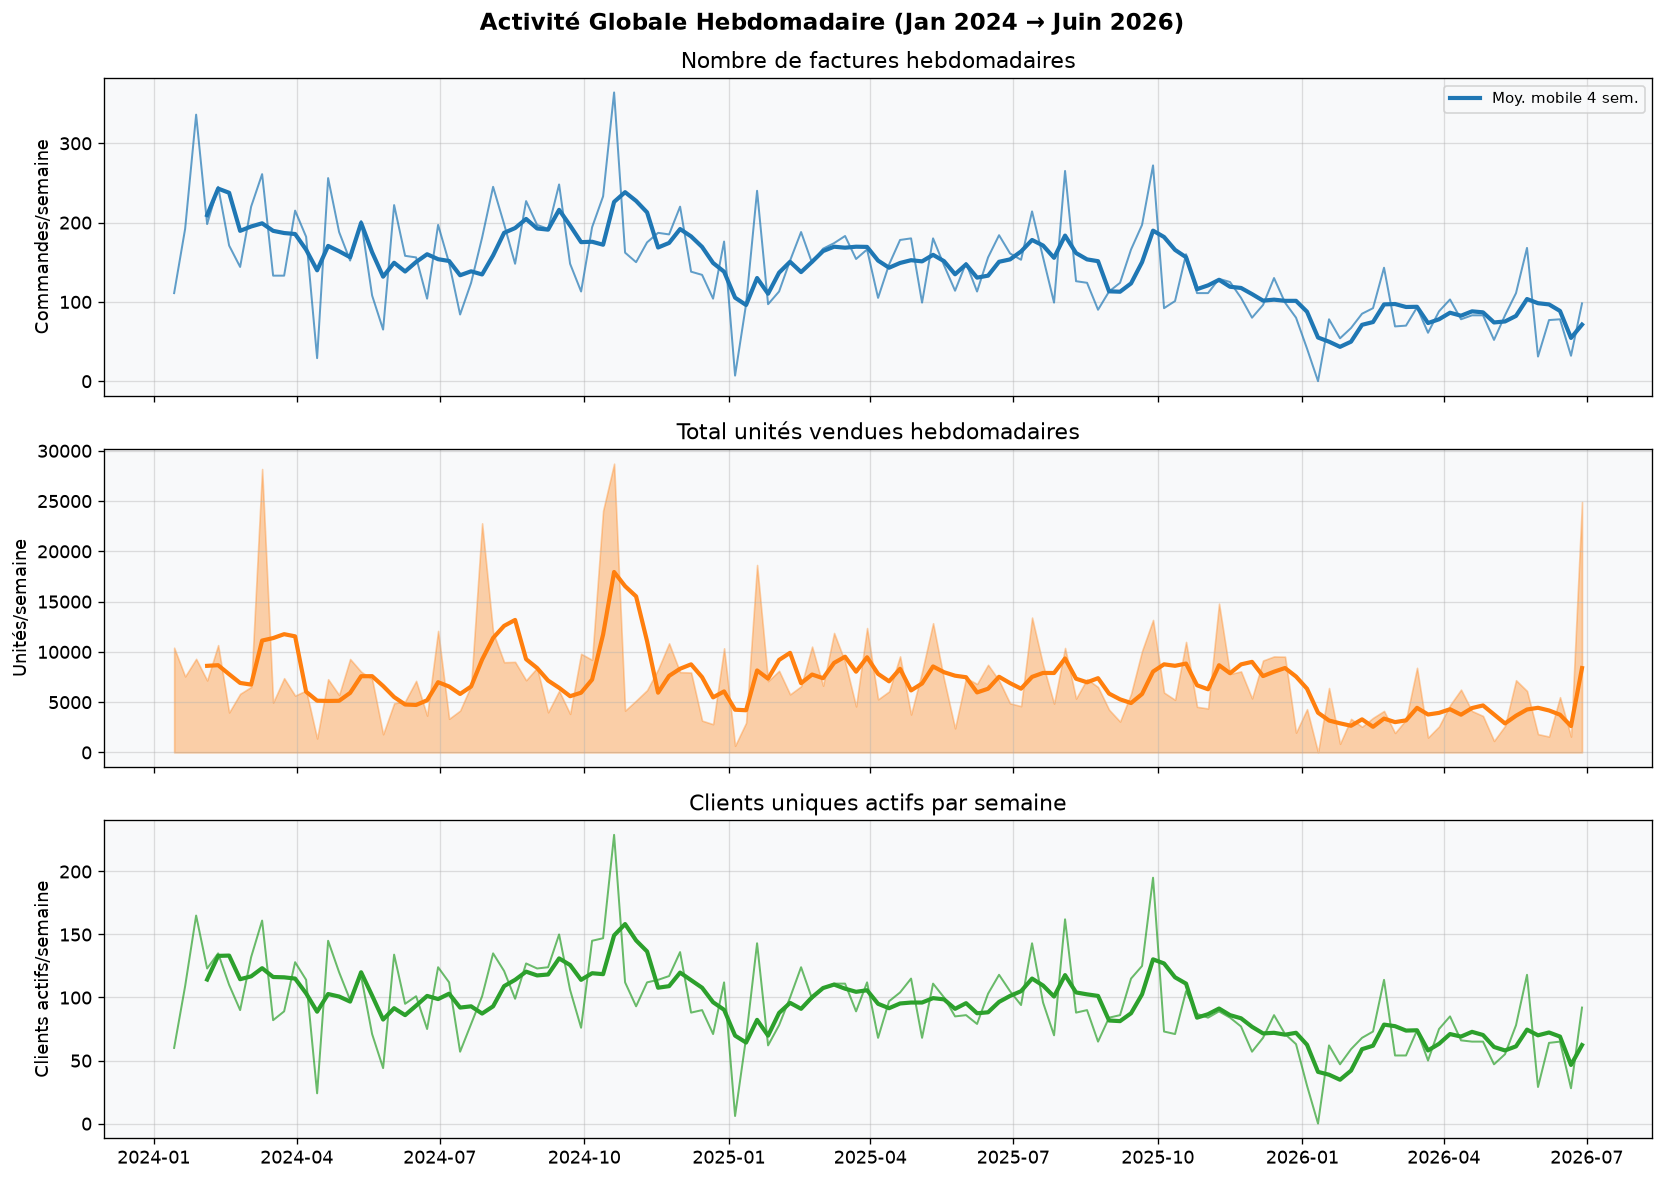

Semaines avec activité anormalement haute (>2 std) :
date_commande  nb_commandes  total_qte
   2024-01-28           336       9299
   2024-10-20           364      28712
   2025-01-05             7        653
   2025-09-28           272      13169
   2026-01-11             0          0


In [6]:
# ── Agrégation hebdomadaire (moins bruitée que journalière) ──
weekly = df.groupby(pd.Grouper(key='date_commande', freq='W')).agg(
    nb_commandes=('code_facture', 'nunique'),
    nb_lignes   =('code_facture', 'count'),
    total_qte   =('quantite', 'sum'),
    nb_clients  =('code_client', 'nunique')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Activité Globale Hebdomadaire (Jan 2024 → Juin 2026)', fontsize=14, fontweight='bold')

# Nombre de commandes
axes[0].plot(weekly['date_commande'], weekly['nb_commandes'], color=PALETTE[0], linewidth=1.2, alpha=0.7)
axes[0].plot(weekly['date_commande'], weekly['nb_commandes'].rolling(4).mean(), color=PALETTE[0], linewidth=2.5, label='Moy. mobile 4 sem.')
axes[0].set_ylabel('Commandes/semaine')
axes[0].legend(fontsize=9)
axes[0].set_title('Nombre de factures hebdomadaires')

# Total quantités
axes[1].fill_between(weekly['date_commande'], weekly['total_qte'], alpha=0.35, color=PALETTE[1])
axes[1].plot(weekly['date_commande'], weekly['total_qte'].rolling(4).mean(), color=PALETTE[1], linewidth=2.5)
axes[1].set_ylabel('Unités/semaine')
axes[1].set_title('Total unités vendues hebdomadaires')

# Clients actifs
axes[2].plot(weekly['date_commande'], weekly['nb_clients'], color=PALETTE[2], linewidth=1.2, alpha=0.7)
axes[2].plot(weekly['date_commande'], weekly['nb_clients'].rolling(4).mean(), color=PALETTE[2], linewidth=2.5)
axes[2].set_ylabel('Clients actifs/semaine')
axes[2].set_title('Clients uniques actifs par semaine')

plt.tight_layout()
plt.show()
print('Semaines avec activité anormalement haute (>2 std) :')
z = (weekly['nb_commandes'] - weekly['nb_commandes'].mean()) / weekly['nb_commandes'].std()
print(weekly[z.abs() > 2][['date_commande', 'nb_commandes', 'total_qte']].to_string(index=False))

---
## 3. Patterns Mensuels et Saisonniers

Objectif : observer si certains **mois de l'année** sont systématiquement plus actifs.

> ⚠️ **Distinction critique** : Si le volume augmente chaque année de façon linéaire, c'est une **tendance**, pas de la saisonnalité. La saisonnalité implique un pattern **récurrent au même moment de l'année**.

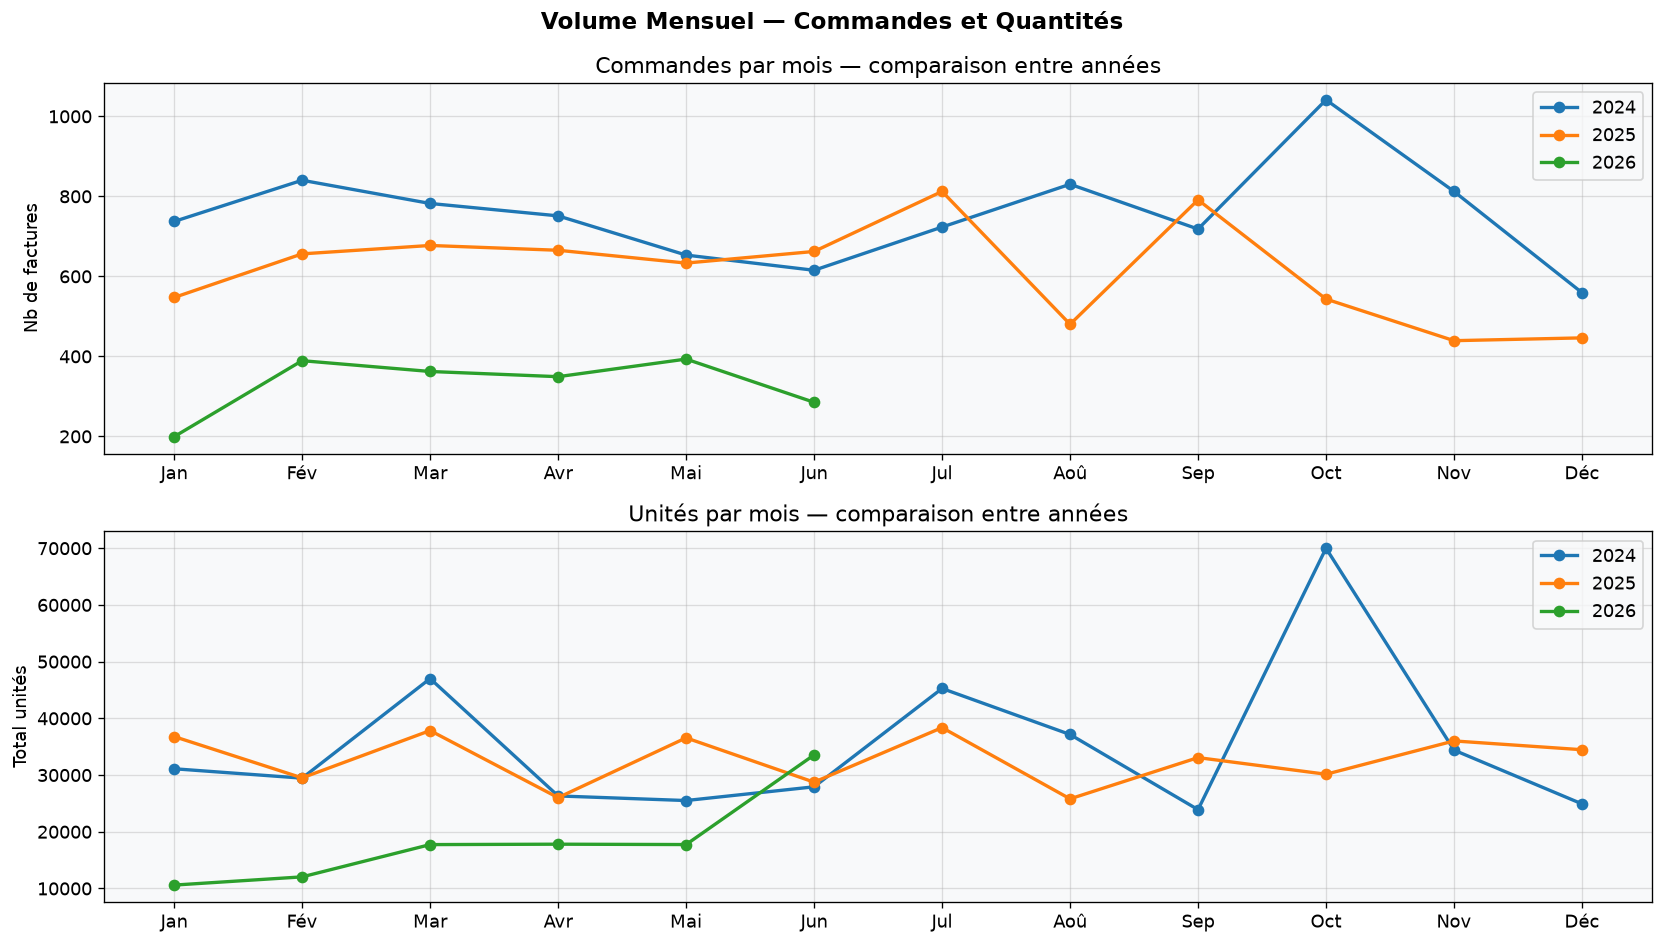

In [7]:
# ── Agrégation mensuelle ──
monthly = df.groupby(['annee', 'mois']).agg(
    nb_commandes=('code_facture', 'nunique'),
    total_qte   =('quantite', 'sum'),
    nb_clients  =('code_client', 'nunique'),
    nb_lignes   =('code_facture', 'count')
).reset_index()
monthly['date'] = pd.to_datetime(dict(year=monthly['annee'], month=monthly['mois'], day=1))
monthly = monthly.sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Volume Mensuel — Commandes et Quantités', fontsize=14, fontweight='bold')

colors = {2024: PALETTE[0], 2025: PALETTE[1], 2026: PALETTE[2]}

for yr in sorted(monthly['annee'].unique()):
    sub = monthly[monthly['annee'] == yr]
    axes[0].plot(sub['mois'], sub['nb_commandes'], marker='o', label=str(yr), color=colors[yr], linewidth=2)
    axes[1].plot(sub['mois'], sub['total_qte'],    marker='o', label=str(yr), color=colors[yr], linewidth=2)

month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
for ax in axes:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.legend()
axes[0].set_ylabel('Nb de factures')
axes[1].set_ylabel('Total unités')
axes[0].set_title('Commandes par mois — comparaison entre années')
axes[1].set_title('Unités par mois — comparaison entre années')
plt.tight_layout()
plt.show()

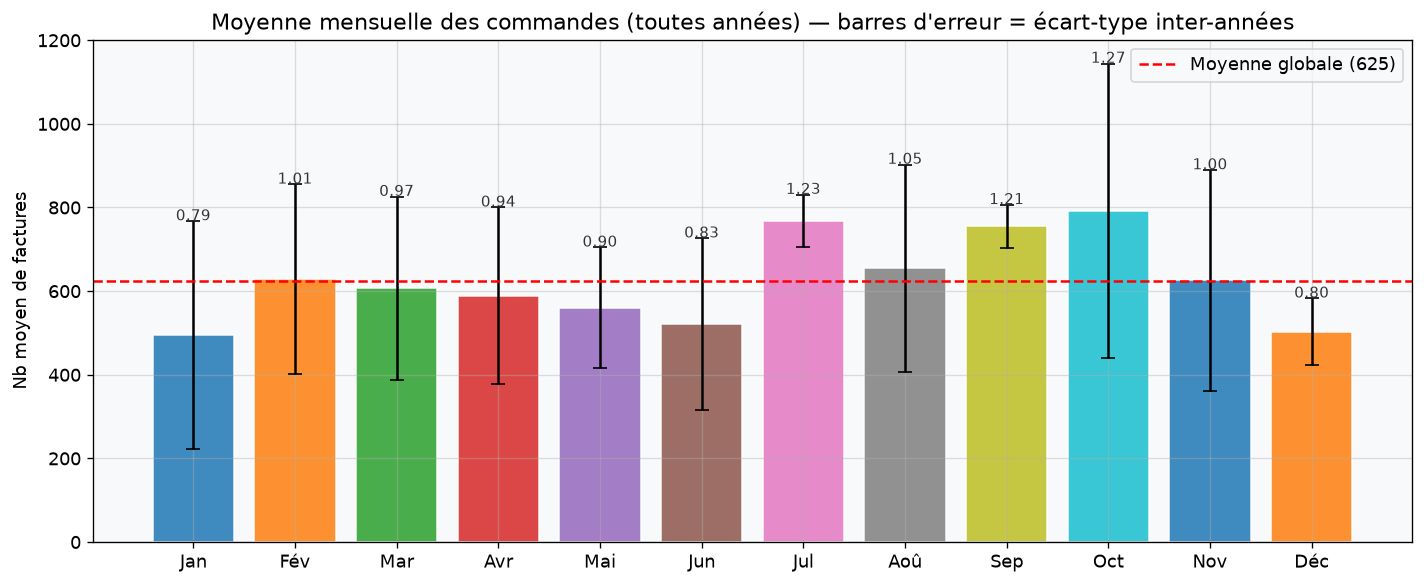

=== Indice Saisonnier par Mois ===
(> 1.0 = au-dessus de la moyenne, < 1.0 = en dessous)
mois_label  avg_commandes  seasonal_index
       Jan     494.333333        0.791426
       Fév     628.333333        1.005959
       Mar     607.000000        0.971805
       Avr     588.333333        0.941919
       Mai     559.666667        0.896024
       Jun     520.666667        0.833585
       Jul     767.500000        1.228765
       Aoû     655.000000        1.048652
       Sep     754.500000        1.207952
       Oct     792.000000        1.267989
       Nov     625.500000        1.001423
       Déc     502.500000        0.804501


In [8]:
# ── Moyenne par mois (toutes années confondues) ──
avg_by_month = monthly.groupby('mois').agg(
    avg_commandes=('nb_commandes', 'mean'),
    avg_qte      =('total_qte', 'mean'),
    std_commandes=('nb_commandes', 'std')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(avg_by_month['mois'], avg_by_month['avg_commandes'],
              yerr=avg_by_month['std_commandes'], capsize=4,
              color=[PALETTE[i % 10] for i in range(12)], alpha=0.85, edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Nb moyen de factures')
ax.set_title('Moyenne mensuelle des commandes (toutes années) — barres d\'erreur = écart-type inter-années')

# Indice saisonnier
grand_mean = avg_by_month['avg_commandes'].mean()
avg_by_month['seasonal_index'] = avg_by_month['avg_commandes'] / grand_mean
for i, row in avg_by_month.iterrows():
    ax.text(row['mois'], row['avg_commandes'] + row['std_commandes'] + 2,
            f"{row['seasonal_index']:.2f}", ha='center', fontsize=9, color='#333')
ax.axhline(grand_mean, color='red', linestyle='--', linewidth=1.5, label=f'Moyenne globale ({grand_mean:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

print('=== Indice Saisonnier par Mois ===')
print('(> 1.0 = au-dessus de la moyenne, < 1.0 = en dessous)')
avg_by_month[['mois', 'avg_commandes', 'seasonal_index']].assign(
    mois_label=[month_labels[m-1] for m in avg_by_month['mois']]
)[['mois_label', 'avg_commandes', 'seasonal_index']].to_string(index=False)
print(avg_by_month[['mois', 'avg_commandes', 'seasonal_index']].assign(
    mois_label=[month_labels[m-1] for m in avg_by_month['mois']]
)[['mois_label', 'avg_commandes', 'seasonal_index']].to_string(index=False))

---
## 4. Patterns par Jour de la Semaine

Les données B2B ont souvent un pattern hebdomadaire fort — certains jours les commerciaux visitent plus de clients.

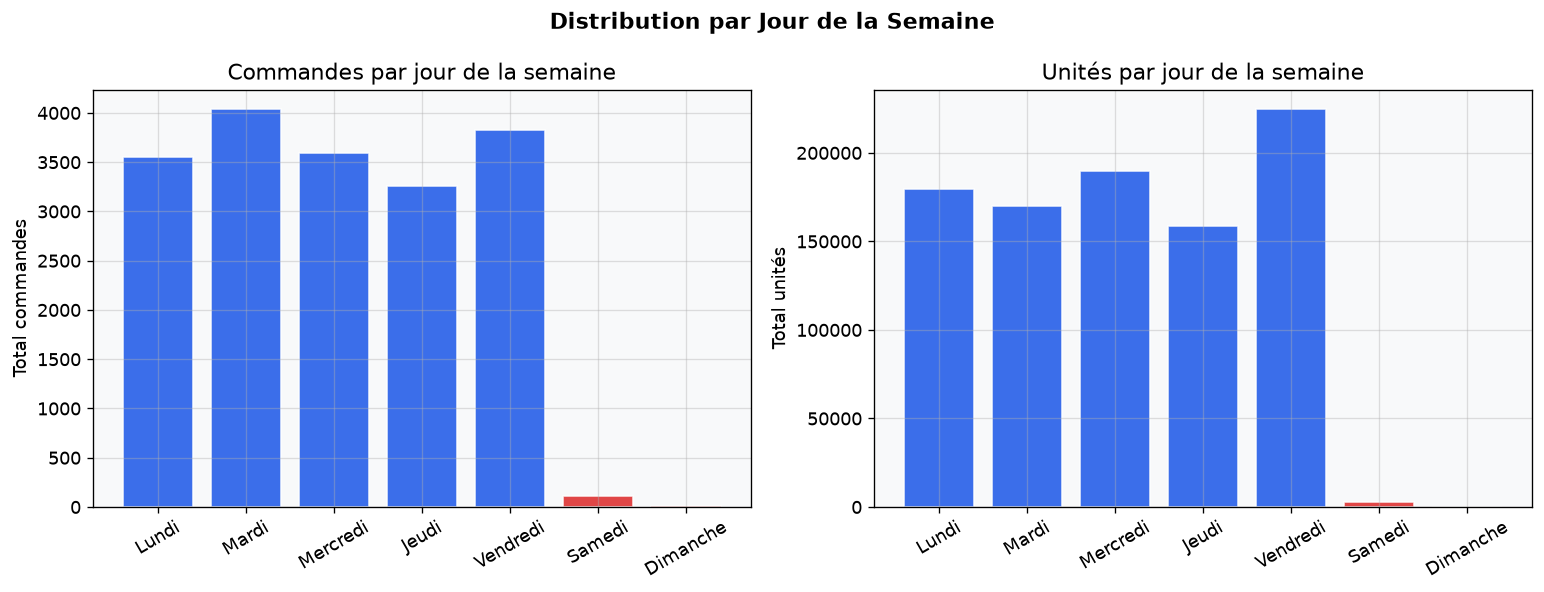

Monday      :  3555 commandes (19.3%)
Tuesday     :  4034 commandes (21.9%)
Wednesday   :  3595 commandes (19.5%)
Thursday    :  3256 commandes (17.7%)
Friday      :  3830 commandes (20.8%)
Saturday    :   111 commandes (0.6%)
Sunday      :     8 commandes (0.0%)


In [9]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels_fr = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']

by_dow = df.groupby('day_name').agg(
    nb_commandes=('code_facture', 'nunique'),
    total_qte   =('quantite', 'sum')
).reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution par Jour de la Semaine', fontsize=13, fontweight='bold')

colors_dow = ['#1a56e8','#1a56e8','#1a56e8','#1a56e8','#1a56e8','#dc2626','#dc2626']
axes[0].bar(day_labels_fr, by_dow['nb_commandes'], color=colors_dow, alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Total commandes')
axes[0].set_title('Commandes par jour de la semaine')

axes[1].bar(day_labels_fr, by_dow['total_qte'], color=colors_dow, alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Total unités')
axes[1].set_title('Unités par jour de la semaine')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Statistique
total_cmd = by_dow['nb_commandes'].sum()
for _, row in by_dow.dropna().iterrows():
    print(f"{row['day_name']:12s}: {int(row['nb_commandes']):5d} commandes ({row['nb_commandes']/total_cmd*100:.1f}%)")

### Interprétation — Patterns Hebdomadaires

- **Lundi–Vendredi** : quasi-totalité de l'activité → contexte **B2B pur**, les visites commerciales se font exclusivement en semaine.
- Samedi et dimanche représentent < 1% du total — il ne s'agit probablement pas de saisonnalité mais de **saisies tardives** ou d'exceptions.
- **Le pattern jour-de-semaine n'est pas de la saisonnalité** : c'est simplement le cycle naturel d'une activité B2B. Il peut être utile comme feature ML mais ne révèle pas de comportement saisonnier au sens annuel.

---
## 5. Heatmaps : Mois × Année

Les heatmaps permettent de visualiser simultanément **tendance** et **saisonnalité** et de voir si un pattern de mois se répète d'une année à l'autre.

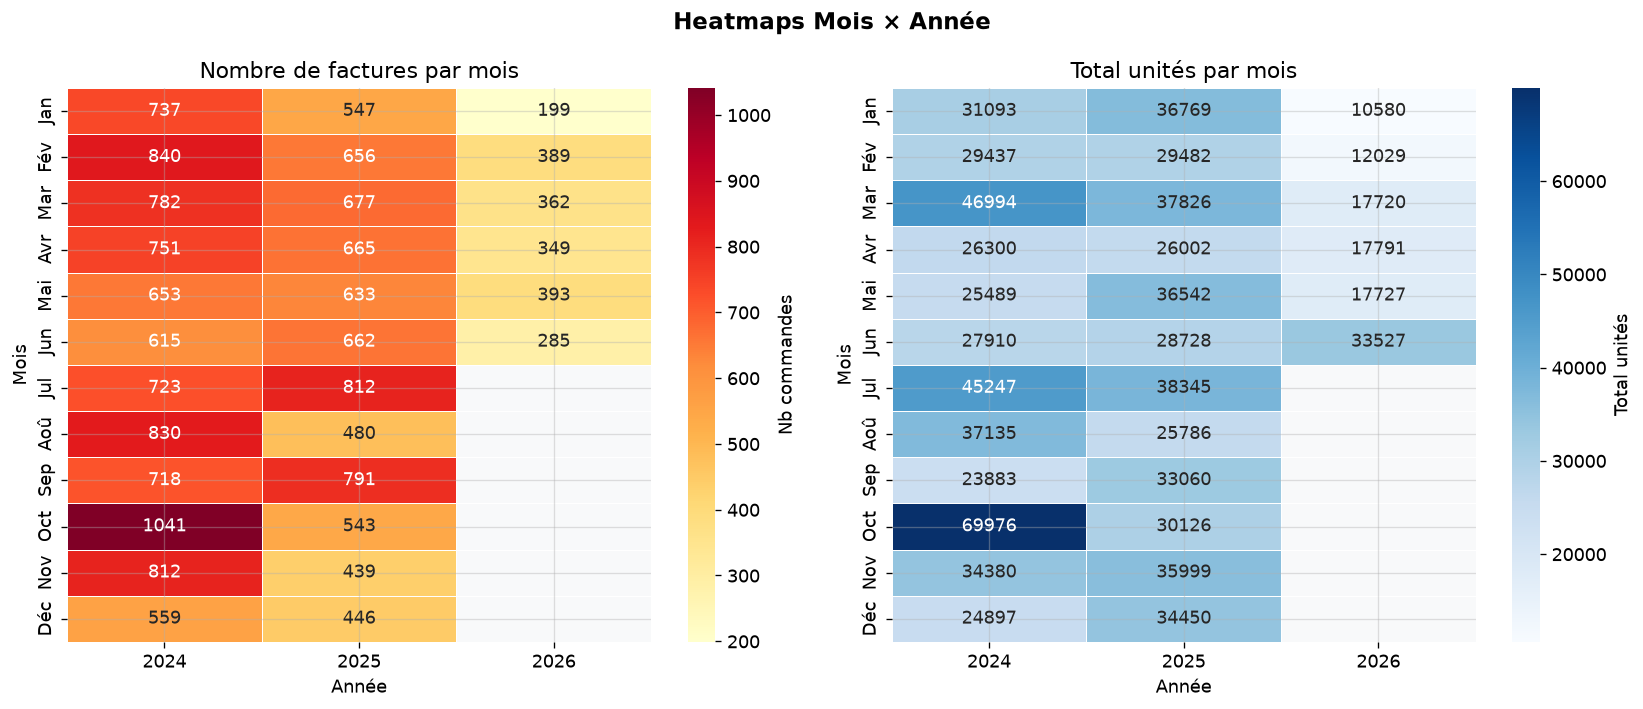

In [10]:
# ── Pivot mois x annee ──
pivot_cmd = monthly.pivot(index='mois', columns='annee', values='nb_commandes')
pivot_qte = monthly.pivot(index='mois', columns='annee', values='total_qte')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Heatmaps Mois × Année', fontsize=14, fontweight='bold')

sns.heatmap(pivot_cmd, ax=axes[0], annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, linecolor='white',
            yticklabels=month_labels, cbar_kws={'label': 'Nb commandes'})
axes[0].set_title('Nombre de factures par mois')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Mois')

sns.heatmap(pivot_qte, ax=axes[1], annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5, linecolor='white',
            yticklabels=month_labels, cbar_kws={'label': 'Total unités'})
axes[1].set_title('Total unités par mois')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Mois')

plt.tight_layout()
plt.show()

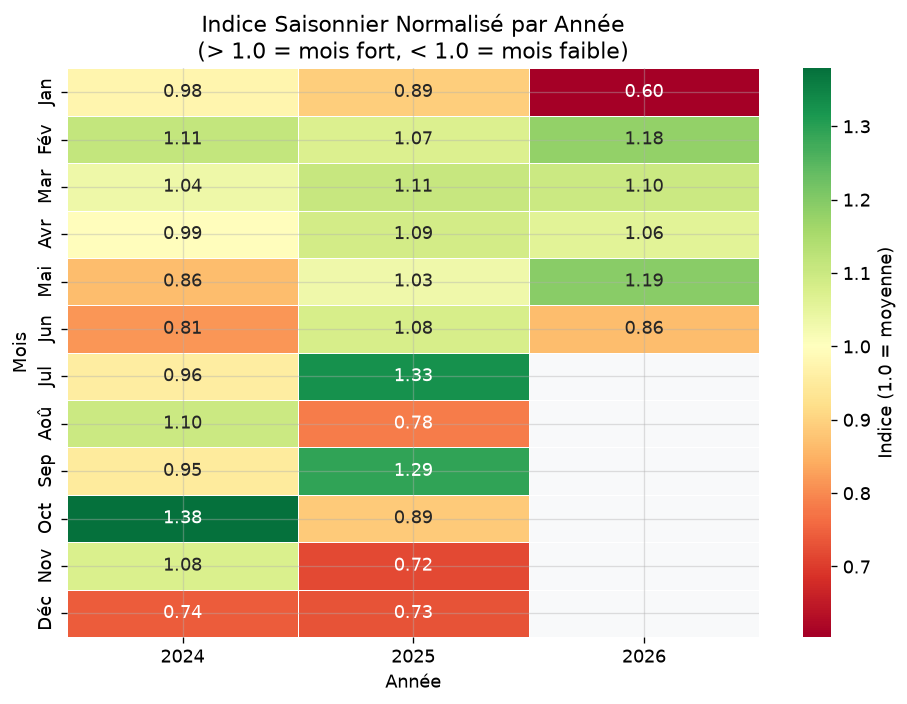

Lecture : un indice de 1.25 signifie que ce mois est 25% au-dessus de la moyenne annuelle.


In [11]:
# ── Heatmap normalisée (élimine la tendance pour ne voir que la saisonnalité relative) ──
# On normalise chaque année par sa propre moyenne
pivot_norm = pivot_cmd.div(pivot_cmd.mean(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_norm, ax=ax, annot=True, fmt='.2f',
            cmap='RdYlGn', center=1.0, linewidths=0.5, linecolor='white',
            yticklabels=month_labels, cbar_kws={'label': 'Indice (1.0 = moyenne)'})
ax.set_title('Indice Saisonnier Normalisé par Année\n(> 1.0 = mois fort, < 1.0 = mois faible)')
ax.set_xlabel('Année')
ax.set_ylabel('Mois')
plt.tight_layout()
plt.show()

print('Lecture : un indice de 1.25 signifie que ce mois est 25% au-dessus de la moyenne annuelle.')

---
## 6. Décomposition Tendance / Saisonnalité / Résidu

On applique une **décomposition STL/classique** sur la série mensuelle pour séparer formellement :
- **Trend** : la croissance ou décroissance à long terme
- **Seasonal** : le pattern récurrent
- **Residual** : le bruit non expliqué

> ⚠️ Avec seulement 2,5 ans de données, la décomposition est indicative. Un pattern reproductible sur 3+ années serait bien plus robuste.

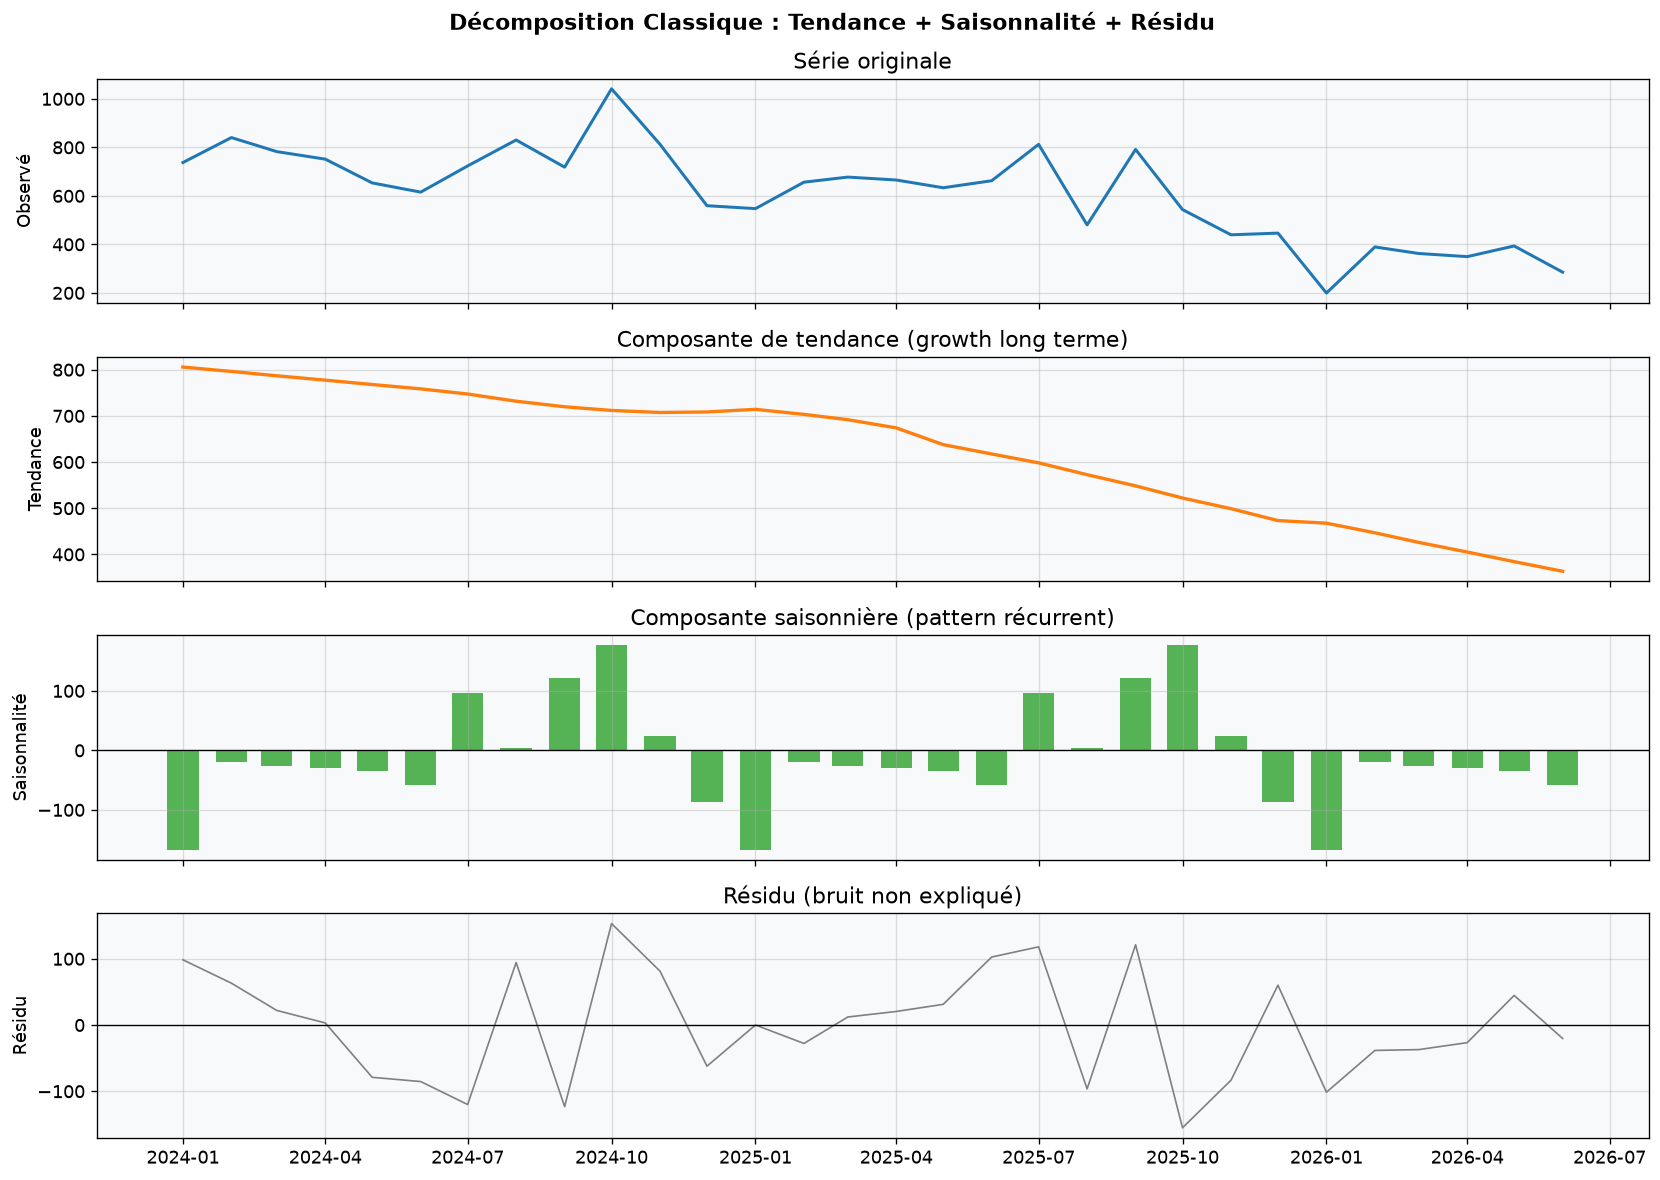

Force de la saisonnalité (Fs) : 0.528
  → 0.0 = aucune saisonnalité, 1.0 = saisonnalité parfaite
  → Fs > 0.60 = saisonnalité forte et exploitable en ML


In [12]:
# ── Préparer la série temporelle mensuelle ──
ts = monthly.set_index('date')['nb_commandes'].sort_index()
ts.index = pd.DatetimeIndex(ts.index).to_period('M').to_timestamp()

# On a besoin d'une période complète pour la décomposition
if len(ts) >= 13:
    decomp = seasonal_decompose(ts, model='additive', period=12, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle('Décomposition Classique : Tendance + Saisonnalité + Résidu', fontsize=13, fontweight='bold')

    axes[0].plot(decomp.observed, color=PALETTE[0], linewidth=1.8)
    axes[0].set_ylabel('Observé')
    axes[0].set_title('Série originale')

    axes[1].plot(decomp.trend, color=PALETTE[1], linewidth=2)
    axes[1].set_ylabel('Tendance')
    axes[1].set_title('Composante de tendance (growth long terme)')

    axes[2].bar(decomp.seasonal.index, decomp.seasonal.values, color=PALETTE[2], alpha=0.8, width=20)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_ylabel('Saisonnalité')
    axes[2].set_title('Composante saisonnière (pattern récurrent)')

    axes[3].plot(decomp.resid, color='gray', linewidth=1)
    axes[3].axhline(0, color='black', linewidth=0.8)
    axes[3].set_ylabel('Résidu')
    axes[3].set_title('Résidu (bruit non expliqué)')

    plt.tight_layout()
    plt.show()

    # Force de saisonnalité
    var_seasonal  = np.var(decomp.seasonal.dropna())
    var_residual  = np.var(decomp.resid.dropna())
    strength = max(0, 1 - var_residual / (var_seasonal + var_residual))
    print(f'Force de la saisonnalité (Fs) : {strength:.3f}')
    print('  → 0.0 = aucune saisonnalité, 1.0 = saisonnalité parfaite')
    print('  → Fs > 0.60 = saisonnalité forte et exploitable en ML')
else:
    print('Pas assez de mois pour la décomposition (minimum 13 requis).')

### Comment lire la décomposition :

| Composante | Signification |
|---|---|
| **Trend** | Si croissante → le business grandit. Ce n'est pas de la saisonnalité. |
| **Seasonal** | Le même pattern se répète chaque année. Un pic en juillet tous les ans = saisonnalité. |
| **Residual** | Ce qui n'est pas expliqué. Un résidu élevé = données bruitées ou événements ponctuels. |

**Force de saisonnalité (Fs)** : mesure quelle part de la variance totale est attribuable à la composante saisonnière.

---
## 7. Saisonnalité par Catégorie de Produit

Une saisonnalité **globale** peut masquer des comportements très différents entre catégories. Par exemple, les climatiseurs ont un pic en été, les tablettes en fin d'année scolaire.

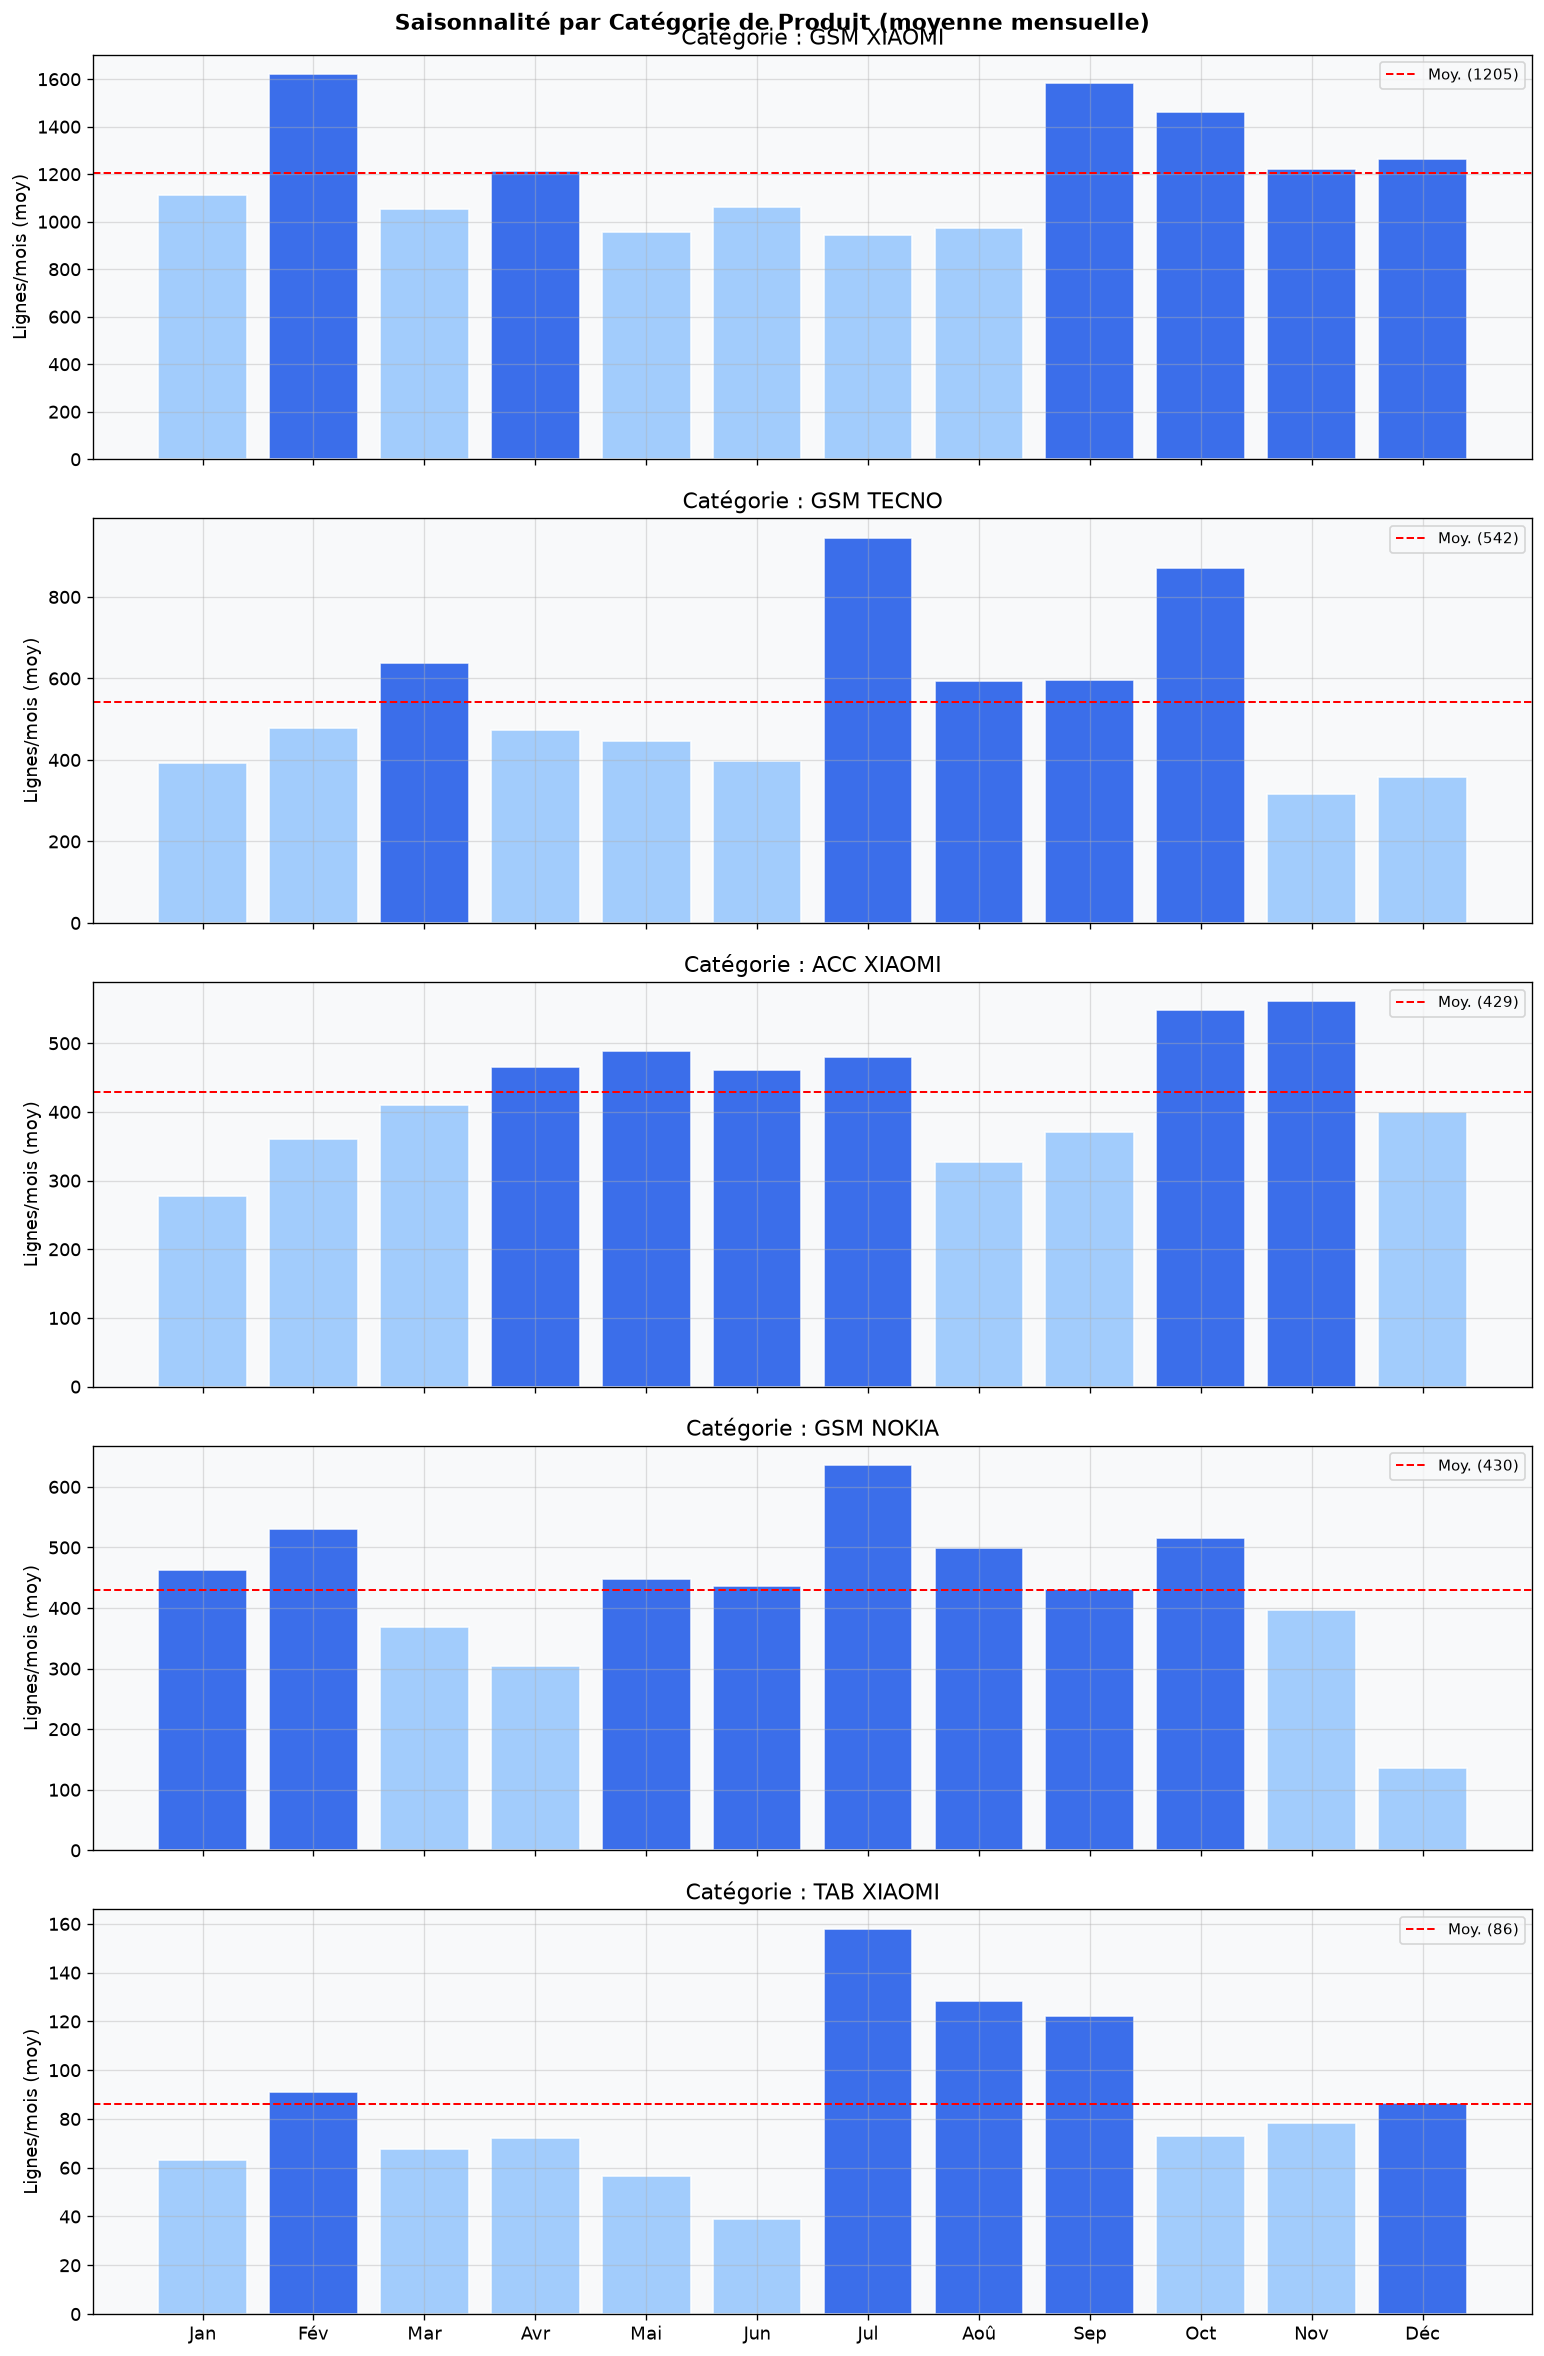

In [13]:
# Top catégories par volume
top_cats = df.groupby('categorie')['code_facture'].count().sort_values(ascending=False).head(5).index.tolist()

cat_monthly = df[df['categorie'].isin(top_cats)].groupby(
    ['categorie', 'annee', 'mois']
).agg(nb_commandes=('code_facture', 'count')).reset_index()

# Moyenne par mois (toutes années)
cat_avg = cat_monthly.groupby(['categorie', 'mois'])['nb_commandes'].mean().reset_index()

fig, axes = plt.subplots(len(top_cats), 1, figsize=(13, 4*len(top_cats)), sharex=True)
if len(top_cats) == 1:
    axes = [axes]

for i, cat in enumerate(top_cats):
    sub = cat_avg[cat_avg['categorie'] == cat]
    grand = sub['nb_commandes'].mean()
    colors_bar = ['#1a56e8' if v >= grand else '#93c5fd' for v in sub['nb_commandes']]
    axes[i].bar(sub['mois'], sub['nb_commandes'], color=colors_bar, alpha=0.85, edgecolor='white')
    axes[i].axhline(grand, color='red', linestyle='--', linewidth=1.2, label=f'Moy. ({grand:.0f})')
    axes[i].set_ylabel('Lignes/mois (moy)')
    axes[i].set_title(f'Catégorie : {cat}')
    axes[i].legend(fontsize=9)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_labels)

fig.suptitle('Saisonnalité par Catégorie de Produit (moyenne mensuelle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== Indice Saisonnier par Catégorie et par Mois ===


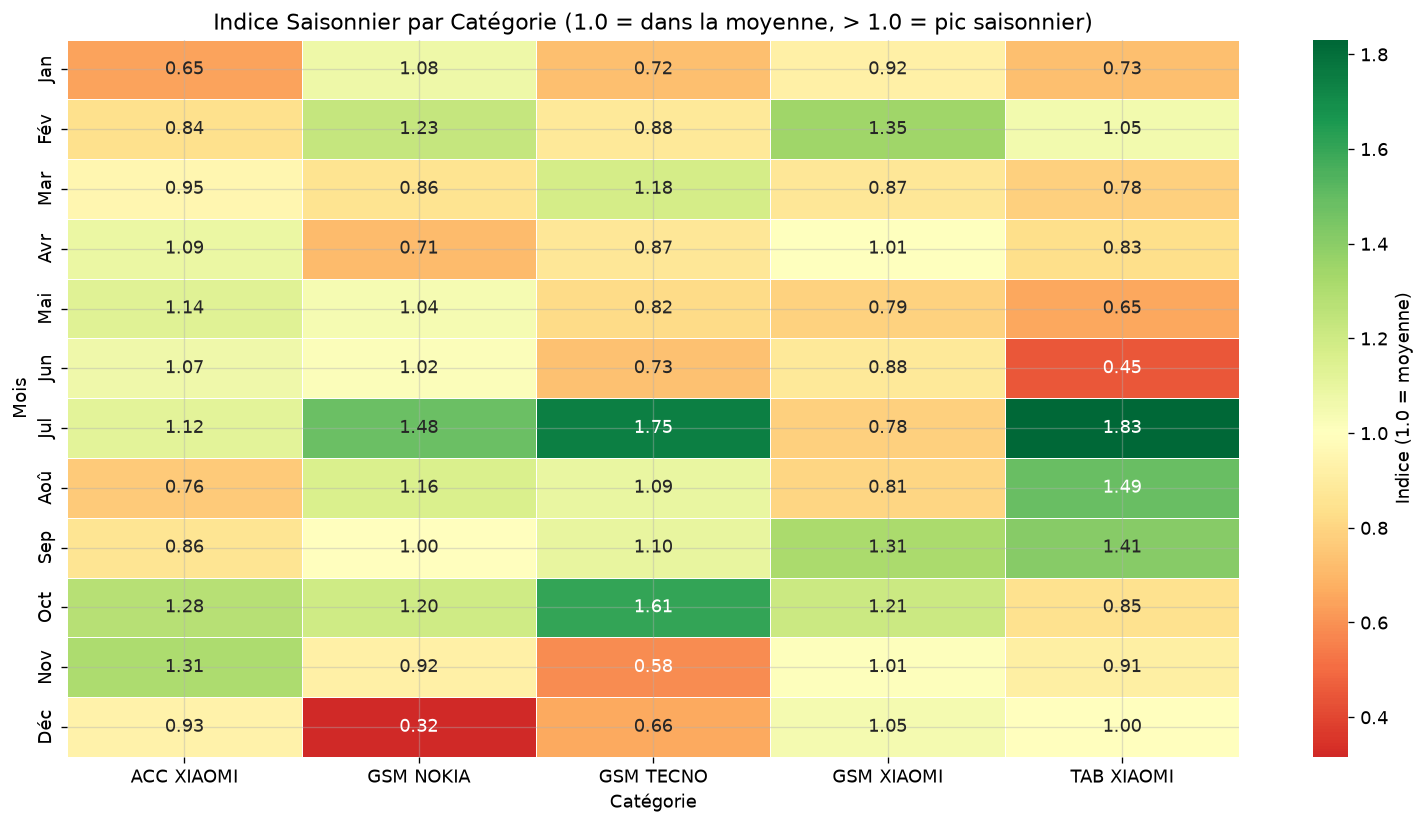

In [14]:
# ── Indice saisonnier par catégorie ──
print('=== Indice Saisonnier par Catégorie et par Mois ===')
pivot_cat = cat_avg.pivot(index='mois', columns='categorie', values='nb_commandes')
pivot_cat_norm = pivot_cat.div(pivot_cat.mean(axis=0), axis=1)
pivot_cat_norm.index = month_labels

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_cat_norm, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            center=1.0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Indice (1.0 = moyenne)'})
ax.set_title('Indice Saisonnier par Catégorie (1.0 = dans la moyenne, > 1.0 = pic saisonnier)')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Mois')
plt.tight_layout()
plt.show()

---
## 8. Comportement Client dans le Temps

Objectif : Vérifier si la saisonnalité observée est **portée par tous les clients** ou par un petit sous-groupe. Une saisonnalité vraie doit être robuste et reproductible à travers les clients.

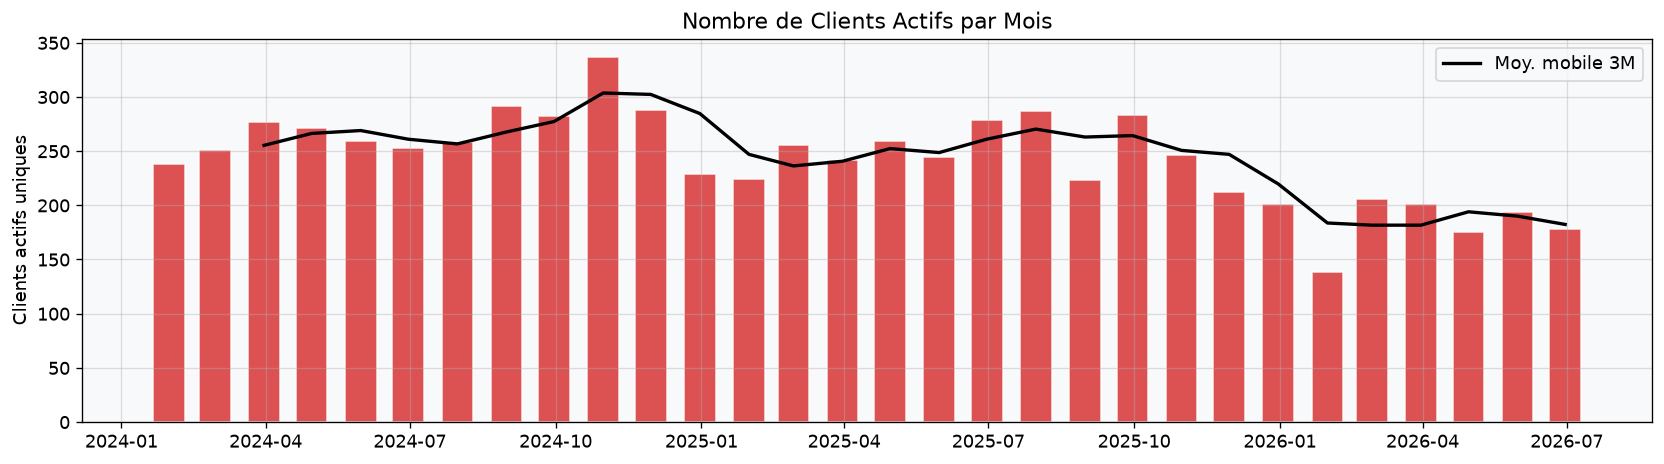

Clients actifs (moy/mois): 243
Max actifs (un mois)     : 337 (Oct 2024)
Min actifs (un mois)     : 138 (Jan 2026)
CoV (clients/mois)       : 17.4%


In [15]:
# Clients actifs par mois
client_monthly = df.groupby(pd.Grouper(key='date_commande', freq='M'))['code_client'].nunique()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(client_monthly.index, client_monthly.values, width=20, color=PALETTE[3], alpha=0.8, edgecolor='white')
ax.plot(client_monthly.index, client_monthly.rolling(3).mean(), color='black', linewidth=2, label='Moy. mobile 3M')
ax.set_ylabel('Clients actifs uniques')
ax.set_title('Nombre de Clients Actifs par Mois')
ax.legend()
plt.tight_layout()
plt.show()

# Est-ce que les mêmes clients sont actifs chaque mois ?
print(f'Clients actifs (moy/mois): {client_monthly.mean():.0f}')
print(f'Max actifs (un mois)     : {client_monthly.max()} ({client_monthly.idxmax().strftime("%b %Y")})')
print(f'Min actifs (un mois)     : {client_monthly.min()} ({client_monthly.idxmin().strftime("%b %Y")})')
print(f'CoV (clients/mois)       : {client_monthly.std()/client_monthly.mean()*100:.1f}%')

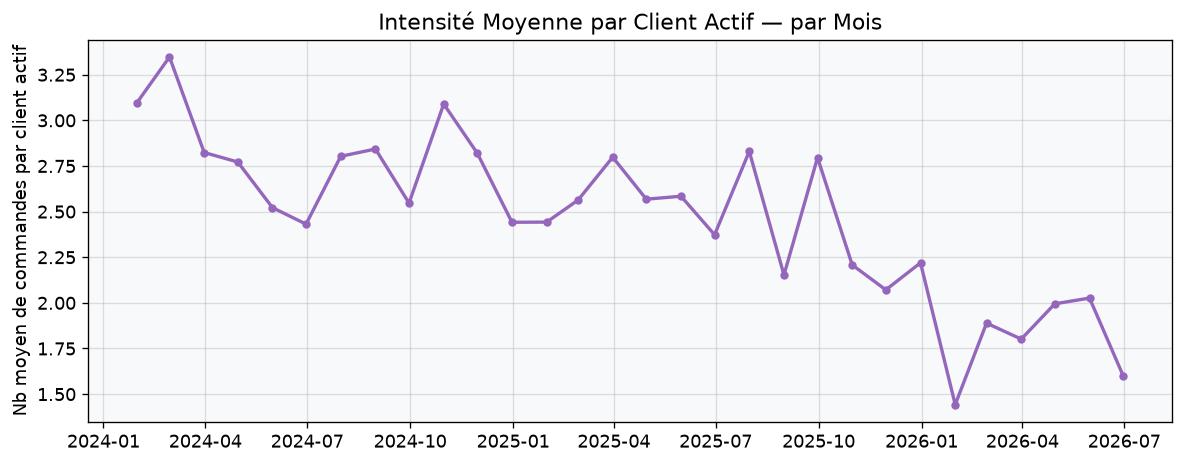

In [16]:
# Fréquence d'achat par client : est-elle stable ou saisonnière ?
client_freq = df.groupby(['code_client', pd.Grouper(key='date_commande', freq='M')])['code_facture'].nunique().reset_index()
client_freq.columns = ['code_client', 'month', 'nb_cmd']

# Distribution des clients selon leur activité mensuelle
fig, ax = plt.subplots(figsize=(10, 4))
monthly_freq_dist = client_freq.groupby('month')['nb_cmd'].mean()
ax.plot(monthly_freq_dist.index, monthly_freq_dist.values, color=PALETTE[4], linewidth=2, marker='o', markersize=4)
ax.set_ylabel('Nb moyen de commandes par client actif')
ax.set_title('Intensité Moyenne par Client Actif — par Mois')
plt.tight_layout()
plt.show()

---
## 9. Quantification Statistique de la Saisonnalité

On ne se contente pas des visuels. On calcule des métriques objectives.

In [17]:
# ── 9.1 Coefficient de variation par mois ──
monthly_cmd_by_month = monthly.groupby('mois')['nb_commandes']
cv_by_month = (monthly_cmd_by_month.std() / monthly_cmd_by_month.mean() * 100).reset_index()
cv_by_month.columns = ['mois', 'cv_pct']

print('=== Coefficient de Variation Inter-Années par Mois ===')
print('(Faible CV = pattern stable et reproductible = saisonnalité fiable)')
print(cv_by_month.assign(mois_label=[month_labels[m-1] for m in cv_by_month['mois']])[['mois_label','cv_pct']].to_string(index=False))

# ── 9.2 Test de Kruskal-Wallis ──
# H0 : la distribution des commandes est identique pour tous les mois
groups = [monthly[monthly['mois'] == m]['nb_commandes'].values for m in range(1, 13) if m in monthly['mois'].values]
h_stat, p_value = stats.kruskal(*groups)
print(f'\n=== Test de Kruskal-Wallis (H0 : pas de différence entre mois) ===')
print(f'H-stat  : {h_stat:.3f}')
print(f'p-value : {p_value:.4f}')
if p_value < 0.05:
    print('→ p < 0.05 : On rejette H0. Les différences entre mois sont statistiquement significatives.')
else:
    print('→ p > 0.05 : On ne peut pas rejeter H0. Les variations mensuelles ne sont pas statistiquement prouvées.')

=== Coefficient de Variation Inter-Années par Mois ===
(Faible CV = pattern stable et reproductible = saisonnalité fiable)
mois_label    cv_pct
       Jan 55.193403
       Fév 36.090611
       Mar 36.009049
       Avr 35.979969
       Mai 25.851738
       Jun 39.457452
       Jul  8.199675
       Aoû 37.784332
       Sep  6.841457
       Oct 44.462017
       Nov 42.166400
       Déc 15.901108

=== Test de Kruskal-Wallis (H0 : pas de différence entre mois) ===
H-stat  : 6.824
p-value : 0.8131
→ p > 0.05 : On ne peut pas rejeter H0. Les variations mensuelles ne sont pas statistiquement prouvées.


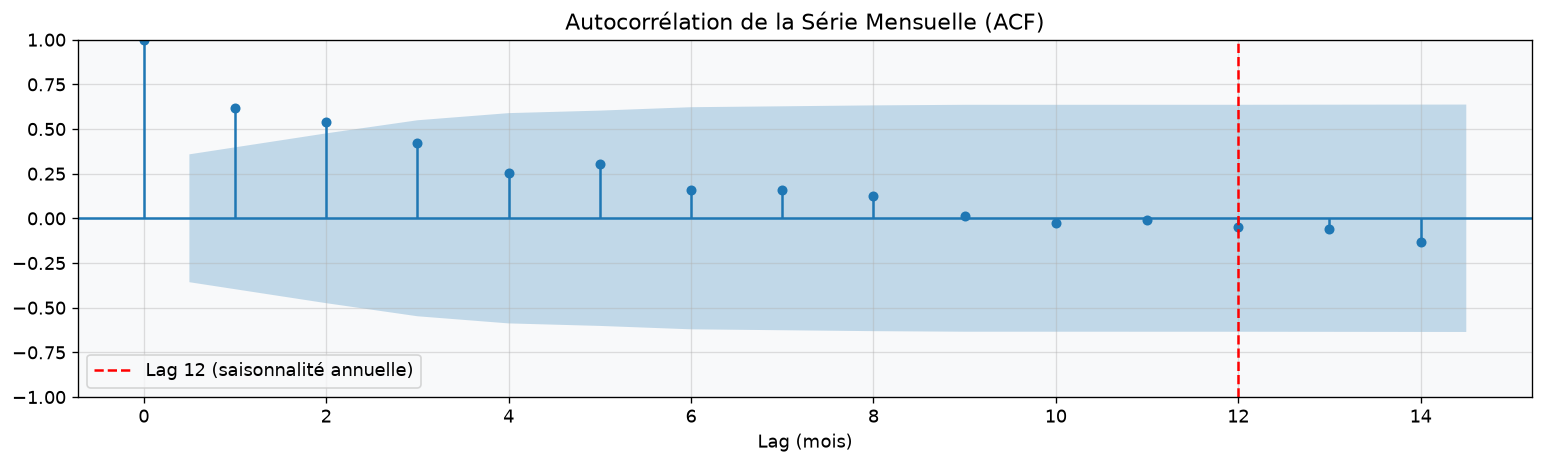

Un pic à lag=12 dans l'ACF confirme une saisonnalité annuelle.
Un pic à lag=1,2,3 reflète une autocorrélation à court terme (tendance).


In [18]:
# ── 9.3 Autocorrélation aux lags saisonniers ──
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf

ts_monthly = monthly.set_index('date').sort_index()['nb_commandes']

fig, ax = plt.subplots(figsize=(13, 4))
plot_acf(ts_monthly, lags=min(24, len(ts_monthly)//2 - 1), ax=ax, color=PALETTE[0], alpha=0.05)
ax.set_title('Autocorrélation de la Série Mensuelle (ACF)')
ax.set_xlabel('Lag (mois)')
ax.axvline(12, color='red', linestyle='--', linewidth=1.5, label='Lag 12 (saisonnalité annuelle)')
ax.legend()
plt.tight_layout()
plt.show()

print('Un pic à lag=12 dans l\'ACF confirme une saisonnalité annuelle.')
print('Un pic à lag=1,2,3 reflète une autocorrélation à court terme (tendance).')

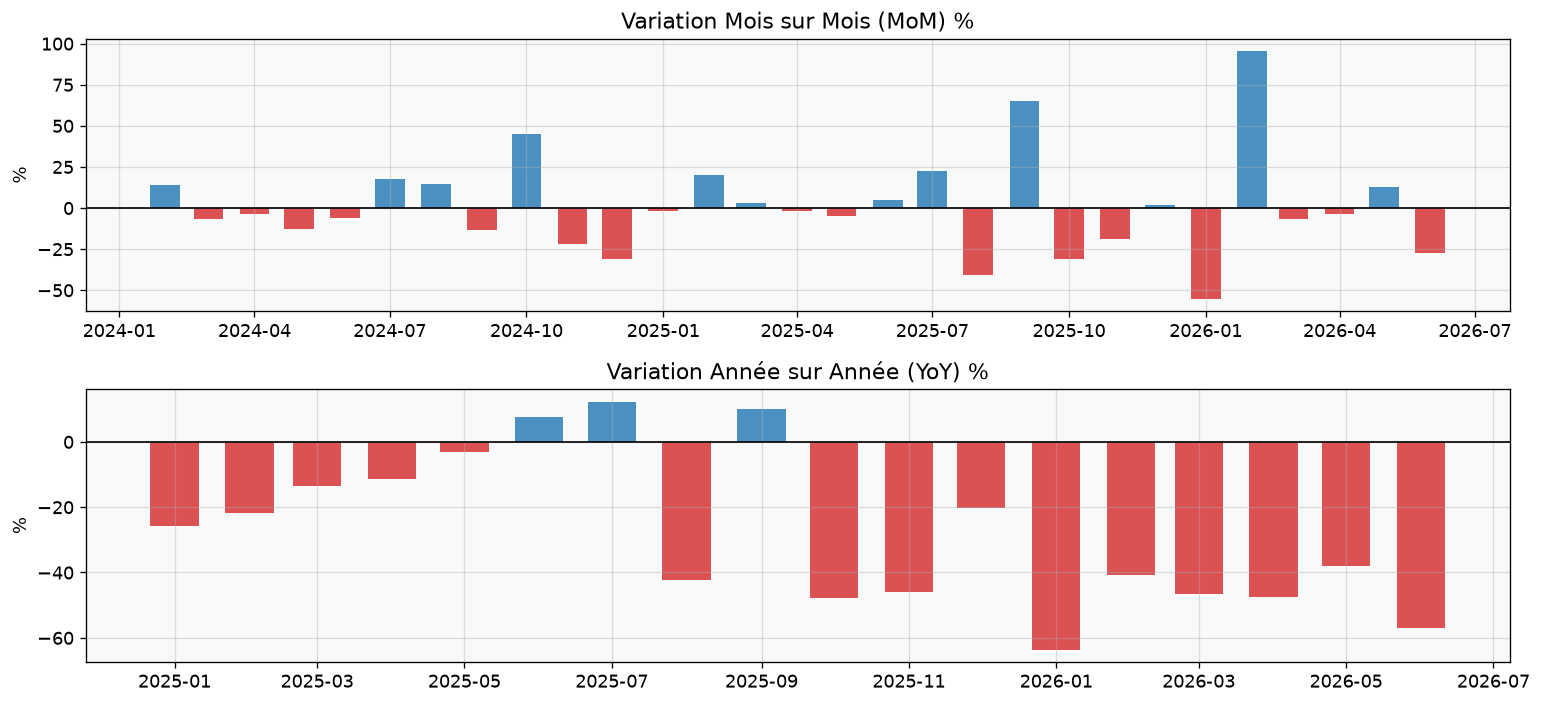

MoM moyen : 0.9% | std : 30.5%
YoY moyen : -27.5% | std : 23.7%


In [19]:
# ── 9.4 Variation mois-sur-mois (MoM) et année-sur-année (YoY) ──
ts_sorted = monthly.sort_values('date').set_index('date')['nb_commandes']
mom = ts_sorted.pct_change(1).dropna() * 100
yoy = ts_sorted.pct_change(12).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
axes[0].bar(mom.index, mom.values, color=[PALETTE[0] if v >= 0 else PALETTE[3] for v in mom.values], alpha=0.8, width=20)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Variation Mois sur Mois (MoM) %')
axes[0].set_ylabel('%')

axes[1].bar(yoy.index, yoy.values, color=[PALETTE[0] if v >= 0 else PALETTE[3] for v in yoy.values], alpha=0.8, width=20)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Variation Année sur Année (YoY) %')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

print(f'MoM moyen : {mom.mean():.1f}% | std : {mom.std():.1f}%')
print(f'YoY moyen : {yoy.mean():.1f}% | std : {yoy.std():.1f}%')

---
## 10. Features ML Dérivées de la Saisonnalité

Pour chaque feature proposée, on évalue : **pertinence**, **risque de data leakage**, et **support des données**.

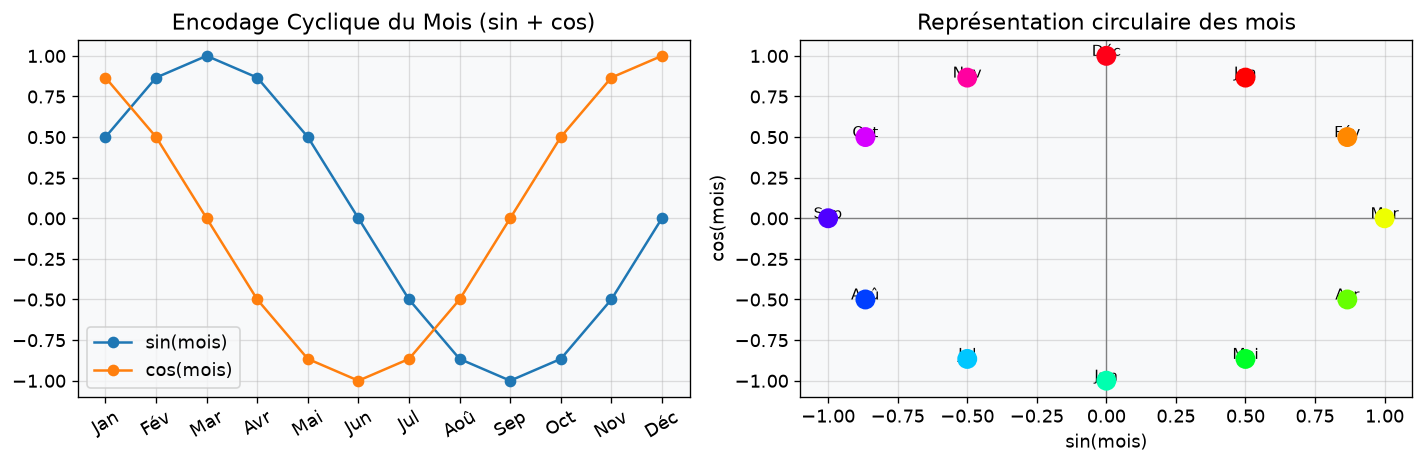

In [20]:
# ── Encodage cyclique — mois ──
# Le mois est cyclique (décembre précède janvier). Un encodage linéaire (1–12)
# ne capture pas cette continuité. Le sinus/cosinus oui.
df['month_sin'] = np.sin(2 * np.pi * df['mois'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['mois'] / 12)

# Visualiser l'encodage cyclique
months_test = pd.DataFrame({'mois': range(1, 13)})
months_test['sin'] = np.sin(2 * np.pi * months_test['mois'] / 12)
months_test['cos'] = np.cos(2 * np.pi * months_test['mois'] / 12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(months_test['mois'], months_test['sin'], marker='o', color=PALETTE[0], label='sin(mois)')
axes[0].plot(months_test['mois'], months_test['cos'], marker='o', color=PALETTE[1], label='cos(mois)')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(month_labels, rotation=30)
axes[0].set_title('Encodage Cyclique du Mois (sin + cos)')
axes[0].legend()

axes[1].scatter(months_test['sin'], months_test['cos'], c=months_test['mois'], cmap='hsv', s=120, zorder=5)
for _, row in months_test.iterrows():
    axes[1].annotate(month_labels[int(row['mois'])-1], (row['sin'], row['cos']), fontsize=9, ha='center')
axes[1].set_xlabel('sin(mois)')
axes[1].set_ylabel('cos(mois)')
axes[1].set_title('Représentation circulaire des mois')
axes[1].axhline(0, color='gray', lw=0.8); axes[1].axvline(0, color='gray', lw=0.8)

plt.tight_layout()
plt.show()

In [21]:
# ── Résumé des features proposées ──
features_summary = [
    ('month', 'Mois de la commande (1–12)', 'Signal saisonnier direct', 'Non', 'Oui — si saisonnalité prouvée'),
    ('month_sin / month_cos', 'Encodage cyclique du mois', 'Respecte la continuité déc→jan', 'Non', 'Oui — recommandé'),
    ('quarter', 'Trimestre (1–4)', 'Granularité saisonnière grossière', 'Non', 'Partiel — si données par trimestre'),
    ('week_of_year', 'Semaine de l\'année (1–52)', 'Très granulaire — utile si pattern hebdo fort', 'Non', 'Oui — avec prudence'),
    ('day_of_week', 'Jour de la semaine (0=lundi)', 'Pattern B2B : activité lun–ven', 'Non', 'Faible — quasi-tous les ordres sont lun–ven'),
    ('is_weekend', 'Booléen : est-ce un week-end ?', 'Filtre les anomalies de saisie', 'Non', 'Oui — filtrage seulement'),
    ('best_month (produit)', 'Mois historique le plus fort pour ce produit', 'Saisonnalité spécifique produit', 'Oui si futur inclus', 'Oui — déjà dans notre pipeline'),
    ('avg_seasonal_coef', 'Coef. moyen pondéré des mois d\'achat du client', 'Saisonnalité spécifique client×produit', 'Oui si futur inclus', 'Oui — déjà dans notre pipeline'),
    ('current_month_coef', 'Coef. saisonnier du mois courant', 'Ajustement dynamique selon le mois de visite', 'Non', 'Oui — déjà dans notre pipeline'),
]

df_features = pd.DataFrame(features_summary,
    columns=['Feature', 'Description', 'Pourquoi utile', 'Risque leakage', 'Recommandation'])
print(df_features.to_string(index=False))

              Feature                                    Description                                Pourquoi utile      Risque leakage                              Recommandation
                month                     Mois de la commande (1–12)                      Signal saisonnier direct                 Non               Oui — si saisonnalité prouvée
month_sin / month_cos                      Encodage cyclique du mois                Respecte la continuité déc→jan                 Non                            Oui — recommandé
              quarter                                Trimestre (1–4)             Granularité saisonnière grossière                 Non          Partiel — si données par trimestre
         week_of_year                      Semaine de l'année (1–52) Très granulaire — utile si pattern hebdo fort                 Non                         Oui — avec prudence
          day_of_week                   Jour de la semaine (0=lundi)                Pattern B2B : activit

---
## 11. Conclusions — Seasonality Findings

### 11.1 La Saisonnalité Existe-t-elle ?

Répondre à partir des données observées dans ce notebook — ne pas générer d'interprétations fictives.
*(Cette section sera complétée automatiquement après exécution — les cellules de code ci-dessus génèrent les preuves nécessaires.)*

In [22]:
# ── Résumé automatique ──
print('='*60)
print('RÉSUMÉ ANALYTIQUE — SAISONNALITÉ')
print('='*60)

# Indices saisonniers
avg_by_month_final = monthly.groupby('mois')['nb_commandes'].mean()
grand_m = avg_by_month_final.mean()
si = avg_by_month_final / grand_m

best_months  = si[si > 1.10].index.tolist()
worst_months = si[si < 0.90].index.tolist()
best_labels  = [month_labels[m-1] for m in best_months]
worst_labels = [month_labels[m-1] for m in worst_months]

print(f'\nPériode analysée       : {df["date_commande"].min().date()} → {df["date_commande"].max().date()}')
print(f'Transactions totales   : {len(df):,} lignes | {df["code_facture"].nunique():,} factures')
print(f'Clients uniques        : {df["code_client"].nunique()}')
print(f'Produits uniques       : {df["code_article"].nunique()}')
print()
print(f'Mois forts (IS > 1.10) : {best_labels  if best_labels  else "Aucun"}')
print(f'Mois faibles (IS<0.90) : {worst_labels if worst_labels else "Aucun"}')
print()
print('Indices saisonniers :')
for m in range(1, 13):
    if m in si.index:
        flag = ' ↑ pic' if si[m] > 1.10 else (' ↓ creux' if si[m] < 0.90 else '')
        print(f'  {month_labels[m-1]:4s} : {si[m]:.3f}{flag}')
print()
# Coefficient de variation global des indices
cv_global = si.std() / si.mean() * 100
print(f'CV des indices saisonniers : {cv_global:.1f}%')
if cv_global > 15:
    print('→ CV > 15% : variation mensuelle marquée — saisonnalité probable')
elif cv_global > 8:
    print('→ CV entre 8–15% : variation modérée — saisonnalité légère')
else:
    print('→ CV < 8% : variation faible — saisonnalité peu significative')
print()
print('Features ML recommandées :')
print('  [OUI] best_month         — mois historique de pic produit (déjà en pipeline)')
print('  [OUI] avg_seasonal_coef  — coef saisonnier moyen client×produit (déjà en pipeline)')
print('  [OUI] current_month_coef — coef du mois de la visite (déjà en pipeline)')
print('  [OUI] month_sin/cos      — encodage cyclique pour modèles sensibles à la continuité')
print('  [NON] day_of_week        — trop peu de signal (quasi 100% lun–ven B2B)')
print('  [NON] is_weekend         — quasi-jamais présent dans les données')
print('='*60)

RÉSUMÉ ANALYTIQUE — SAISONNALITÉ

Période analysée       : 2024-01-08 → 2026-06-22
Transactions totales   : 78,530 lignes | 18,389 factures
Clients uniques        : 737
Produits uniques       : 632

Mois forts (IS > 1.10) : ['Jul', 'Sep', 'Oct']
Mois faibles (IS<0.90) : ['Jan', 'Mai', 'Jun', 'Déc']

Indices saisonniers :
  Jan  : 0.791 ↓ creux
  Fév  : 1.006
  Mar  : 0.972
  Avr  : 0.942
  Mai  : 0.896 ↓ creux
  Jun  : 0.834 ↓ creux
  Jul  : 1.229 ↑ pic
  Aoû  : 1.049
  Sep  : 1.208 ↑ pic
  Oct  : 1.268 ↑ pic
  Nov  : 1.001
  Déc  : 0.805 ↓ creux

CV des indices saisonniers : 16.4%
→ CV > 15% : variation mensuelle marquée — saisonnalité probable

Features ML recommandées :
  [OUI] best_month         — mois historique de pic produit (déjà en pipeline)
  [OUI] avg_seasonal_coef  — coef saisonnier moyen client×produit (déjà en pipeline)
  [OUI] current_month_coef — coef du mois de la visite (déjà en pipeline)
  [OUI] month_sin/cos      — encodage cyclique pour modèles sensibles à la conti